In [1]:
# Boston Influenza GNN Predictor
# Make sure this file is NOT named 'torch_geometric.py' or anything similar!

import pandas as pd
import numpy as np
import sys
import warnings
warnings.filterwarnings('ignore')

# Import torch first
import torch
import torch.nn as nn
import torch.nn.functional as F

# Check if the script filename conflicts with torch_geometric
if 'torch_geometric' in sys.modules:
    print("WARNING: Potential naming conflict detected!")
    print("Make sure your script is not named 'torch_geometric.py'")

# Import PyTorch Geometric with error handling
try:
    import torch_geometric
    from torch_geometric.data import Data, Dataset
    from torch_geometric.nn import GATConv
    from torch_geometric.loader import DataLoader
    print("✓ PyTorch Geometric imported successfully")
except (ImportError, AttributeError) as e:
    print(f"ERROR importing PyTorch Geometric: {e}")
    print("\nTo fix this issue:")
    print("1. Make sure your notebook/script is NOT named 'torch_geometric.py' or 'torch_geometric.ipynb'")
    print("2. Restart your kernel/Python session")
    print("3. If still failing, reinstall PyTorch Geometric:")
    print("   pip uninstall torch-geometric torch-scatter torch-sparse torch-cluster")
    print("   pip install torch-geometric")
    sys.exit(1)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from datetime import datetime, timedelta
import os

# ============================================================================
# DATA LOADING AND PREPROCESSING
# ============================================================================

class InfluenzaDataProcessor:
    """
    Modular data processor that handles multiple data sources with different
    temporal resolutions. Easily extensible for new data types.
    """
    
    def __init__(self):
        self.scalers = {}
        self.neighborhoods = None
        self.neighborhood_to_idx = {}
        
    def load_ed_visits_type1(self, filepath):
        """Load ED visit counts (weekly)"""
        # Read CSV - they are comma-separated, not tab-separated
        df = pd.read_csv(filepath)
        
        # Print columns for debugging
        print(f"   ED Type 1 columns: {list(df.columns)[:5]}...")  # First 5 columns
        
        # Parse date from date_value_end
        df['date'] = pd.to_datetime(df['date_value_end'])
        df['year'] = df['date'].dt.year
        df['week_of_year'] = df['week']
        return df[['year', 'week_of_year', 'value']].rename(columns={'value': 'ed_count'})
    
    def load_ed_visits_type2(self, filepath):
        """Load ED visit percentages (weekly)"""
        df = pd.read_csv(filepath)
        
        print(f"   ED Type 2 columns: {list(df.columns)[:5]}...")
        
        df['date'] = pd.to_datetime(df['date_value_end'])
        df['year'] = df['date'].dt.year
        df['week_of_year'] = df['week']
        return df[['year', 'week_of_year', 'value']].rename(columns={'value': 'ed_percentage'})
    
    def load_demographics(self, filepath):
        """Load demographics data (monthly) - aggregated to city level"""
        df = pd.read_csv(filepath)
        
        print(f"   Demographics columns: {list(df.columns)[:5]}...")
        
        df['date'] = pd.to_datetime(df['date_value_end'])
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        
        # Pivot to get features by demographic category
        pivot = df.pivot_table(
            index=['year', 'month'],
            columns=['demographic_category', 'demographic_value'],
            values='value',
            aggfunc='sum',
            fill_value=0
        )
        pivot.columns = ['_'.join(col).strip() for col in pivot.columns.values]
        return pivot.reset_index()
    
    def load_neighborhood(self, filepath):
        """Load neighborhood-level flu rates (monthly)"""
        df = pd.read_csv(filepath)
        
        print(f"   Neighborhood columns: {list(df.columns)[:5]}...")
        
        df['date'] = pd.to_datetime(df['date_value_end'])
        df['year'] = df['date'].dt.year
        df['month'] = df['date'].dt.month
        df = df.rename(columns={'demographic_value': 'neighborhood', 'value': 'flu_rate'})
        
        # Store unique neighborhoods
        if self.neighborhoods is None:
            self.neighborhoods = sorted(df['neighborhood'].unique())
            self.neighborhood_to_idx = {n: i for i, n in enumerate(self.neighborhoods)}
        
        return df[['year', 'month', 'neighborhood', 'flu_rate']]
    
    def load_wastewater(self, filepath):
        """Load wastewater data (daily) - aggregate to weekly"""
        df = pd.read_csv(filepath)
        
        print(f"   Wastewater columns: {list(df.columns)[:5]}...")
        
        df['date'] = pd.to_datetime(df['date_value_end'])
        df = df.rename(columns={'demographic_value': 'neighborhood', 'value': 'wastewater'})
        
        # Aggregate daily to weekly
        df['year'] = df['date'].dt.year
        df['week_of_year'] = df['date'].dt.isocalendar().week
        
        weekly = df.groupby(['year', 'week_of_year', 'neighborhood'])['wastewater'].mean().reset_index()
        return weekly
    
    def load_vaccination(self, filepath, sheet_name='Influenza Town Data'):
        """Load vaccination data from Excel file"""
        df = pd.read_excel(filepath, sheet_name=sheet_name)
        
        # Filter for Boston
        df = df[df['Town'] == 'Boston'].copy()
        
        df['date'] = pd.to_datetime(df['End Date'])
        df['year'] = df['date'].dt.year
        df['week_of_year'] = df['date'].dt.isocalendar().week
        
        # Convert percentage strings to float
        df['vaccination_pct'] = df['Percent of people vaccinated'].str.rstrip('%').astype(float)
        
        # Pivot by age group
        pivot = df.pivot_table(
            index=['year', 'week_of_year'],
            columns='Subgroup',
            values='vaccination_pct',
            aggfunc='first',
            fill_value=0
        )
        pivot.columns = ['vax_' + col.replace(' ', '_').replace('-', '_') for col in pivot.columns]
        return pivot.reset_index()
    
    def align_temporal_data(self, weekly_df, monthly_df, year_col, week_col):
        """Align monthly data to weekly data using forward fill"""
        # Create a year-month column for monthly data
        if 'month' in monthly_df.columns:
            monthly_df['year_month'] = monthly_df['year'].astype(str) + '-' + monthly_df['month'].astype(str).str.zfill(2)
        
        # Create year-month for weekly data (from week number)
        weekly_df['temp_date'] = pd.to_datetime(
            weekly_df[year_col].astype(str) + '-W' + weekly_df[week_col].astype(str).str.zfill(2) + '-1',
            format='%Y-W%W-%w',
            errors='coerce'
        )
        weekly_df['year_month'] = weekly_df['temp_date'].dt.strftime('%Y-%m')
        
        # Merge
        merged = weekly_df.merge(monthly_df, on='year_month', how='left', suffixes=('', '_monthly'))
        merged = merged.drop(columns=[col for col in merged.columns if col.endswith('_monthly')])
        
        # Forward fill missing values
        feature_cols = [col for col in monthly_df.columns if col not in ['year', 'month', 'year_month']]
        merged[feature_cols] = merged[feature_cols].ffill()
        
        return merged


class InfluenzaGraphDataset(Dataset):
    """
    PyTorch Geometric Dataset for influenza prediction.
    Creates graph structures with neighborhoods as nodes.
    """
    
    def __init__(self, processor, data_dict, lookback_weeks=4, prediction_horizon=1):
        """
        Args:
            processor: InfluenzaDataProcessor instance
            data_dict: Dictionary containing all loaded dataframes
            lookback_weeks: Number of historical weeks to use as features
            prediction_horizon: Number of weeks ahead to predict
        """
        super().__init__()
        self.processor = processor
        self.lookback_weeks = lookback_weeks
        self.prediction_horizon = prediction_horizon
        
        # Prepare the unified dataset
        self.prepare_dataset(data_dict)
        
    def prepare_dataset(self, data_dict):
        """Combine all data sources into a unified weekly dataset"""
        
        # Start with ED visits (our target and temporal anchor)
        if 'ed_type1' in data_dict and 'ed_type2' in data_dict:
            base_df = data_dict['ed_type1'].merge(
                data_dict['ed_type2'],
                on=['year', 'week_of_year'],
                how='outer'
            )
        elif 'ed_type1' in data_dict:
            base_df = data_dict['ed_type1']
        else:
            raise ValueError("At least one ED visits dataset is required")
        
        # Align demographics (city-level, monthly)
        if 'demographics' in data_dict:
            base_df = self.processor.align_temporal_data(
                base_df, data_dict['demographics'], 'year', 'week_of_year'
            )
        
        # Align vaccination data (city-level, variable frequency)
        if 'vaccination' in data_dict:
            base_df = base_df.merge(
                data_dict['vaccination'],
                on=['year', 'week_of_year'],
                how='left'
            )
            vax_cols = [col for col in base_df.columns if col.startswith('vax_')]
            base_df[vax_cols] = base_df[vax_cols].ffill()
        
        # Process neighborhood-level data
        neighborhood_features = {}
        
        # Determine the expected feature columns for neighborhoods
        expected_neigh_features = []
        
        if 'neighborhood' in data_dict:
            expected_neigh_features.append('flu_rate')
            # Align monthly neighborhood data to weekly
            neigh_df = data_dict['neighborhood'].copy()
            for neighborhood in self.processor.neighborhoods:
                neigh_subset = neigh_df[neigh_df['neighborhood'] == neighborhood].copy()
                neigh_subset['year_month'] = (
                    neigh_subset['year'].astype(str) + '-' + 
                    neigh_subset['month'].astype(str).str.zfill(2)
                )
                neighborhood_features[neighborhood] = neigh_subset[['year_month', 'flu_rate']]
        
        if 'wastewater' in data_dict:
            expected_neigh_features.append('wastewater')
            # Wastewater is already weekly
            ww_df = data_dict['wastewater']
            for neighborhood in self.processor.neighborhoods:
                ww_subset = ww_df[ww_df['neighborhood'] == neighborhood][
                    ['year', 'week_of_year', 'wastewater']
                ]
                if neighborhood not in neighborhood_features:
                    neighborhood_features[neighborhood] = ww_subset
                else:
                    # Merge with existing neighborhood data
                    base_temp = base_df[['year', 'week_of_year']].drop_duplicates()
                    base_temp['year_month'] = pd.to_datetime(
                        base_temp['year'].astype(str) + '-W' + 
                        base_temp['week_of_year'].astype(str).str.zfill(2) + '-1',
                        format='%Y-W%W-%w',
                        errors='coerce'
                    ).dt.strftime('%Y-%m')
                    
                    merged = base_temp.merge(
                        neighborhood_features[neighborhood],
                        on='year_month',
                        how='left'
                    )
                    merged = merged.merge(ww_subset, on=['year', 'week_of_year'], how='left')
                    neighborhood_features[neighborhood] = merged
        
        # Store expected feature dimension
        self.expected_neigh_feature_dim = len(expected_neigh_features)
        self.expected_neigh_features = expected_neigh_features
        
        # Store processed data
        self.base_df = base_df.sort_values(['year', 'week_of_year']).reset_index(drop=True)
        self.neighborhood_features = neighborhood_features
        
        # Debug: Print what features we have
        print(f"   Base DataFrame shape: {self.base_df.shape}")
        print(f"   Base DataFrame columns: {list(self.base_df.columns)}")
        print(f"   Number of neighborhoods with features: {len(neighborhood_features)}")
        print(f"   Expected neighborhood feature dimension: {self.expected_neigh_feature_dim}")
        print(f"   Expected neighborhood features: {self.expected_neigh_features}")
        for neigh, feat_df in list(neighborhood_features.items())[:3]:  # Show first 3
            print(f"   - {neigh}: {feat_df.shape}, columns: {list(feat_df.columns)}")
        
        # Create edge index (simple neighborhood connectivity - can be customized)
        self.edge_index = self.create_edge_index()
        
        # Prepare sequences
        self.prepare_sequences()
    
    def create_edge_index(self):
        """
        Create graph edges. Default: fully connected graph.
        Override this method to implement custom connectivity (e.g., geographic proximity).
        """
        n_nodes = len(self.processor.neighborhoods)
        edges = []
        
        # Fully connected for now - you can customize based on geographic proximity
        for i in range(n_nodes):
            for j in range(n_nodes):
                if i != j:
                    edges.append([i, j])
        
        if len(edges) == 0:
            # If only one neighborhood, create self-loop
            edges = [[0, 0]]
        
        return torch.tensor(edges, dtype=torch.long).t().contiguous()
    
    def prepare_sequences(self):
        """Create sequences for temporal prediction"""
        self.sequences = []
        
        n_weeks = len(self.base_df)
        
        for i in range(self.lookback_weeks, n_weeks - self.prediction_horizon + 1):
            # Historical window
            hist_start = i - self.lookback_weeks
            hist_end = i
            
            # Target week
            target_idx = i + self.prediction_horizon - 1
            
            self.sequences.append({
                'hist_indices': list(range(hist_start, hist_end)),
                'target_idx': target_idx
            })
    
    def len(self):
        return len(self.sequences)
    
    def get(self, idx):
        """Get a single graph sample"""
        seq = self.sequences[idx]
        
        # Extract city-level features for historical weeks
        city_features_list = []
        for week_idx in seq['hist_indices']:
            week_row = self.base_df.iloc[week_idx]
            
            # Get all city-level features (exclude year, week, date columns)
            feature_cols = [col for col in self.base_df.columns 
                          if col not in ['year', 'week_of_year', 'temp_date', 'year_month']]
            
            city_feat = week_row[feature_cols].values.astype(float)
            city_feat = np.nan_to_num(city_feat, nan=0.0)
            city_features_list.append(city_feat)
        
        city_features = np.array(city_features_list)  # Shape: (lookback_weeks, n_city_features)
        
        # Extract neighborhood-level features for historical weeks
        # Use the expected feature dimension determined during dataset preparation
        feature_dim = self.expected_neigh_feature_dim
        neighborhood_features_list = []
        
        for neighborhood in self.processor.neighborhoods:
            neigh_hist = []
            
            if neighborhood in self.neighborhood_features:
                neigh_df = self.neighborhood_features[neighborhood]
                
                for week_idx in seq['hist_indices']:
                    week_row = self.base_df.iloc[week_idx]
                    year_val = week_row['year']
                    week_val = week_row['week_of_year']
                    
                    # Find matching row in neighborhood data
                    match = neigh_df[
                        (neigh_df['year'] == year_val) & 
                        (neigh_df['week_of_year'] == week_val)
                    ]
                    
                    # Extract features in the expected order
                    feats = np.zeros(feature_dim)
                    if len(match) > 0:
                        for i, feat_name in enumerate(self.expected_neigh_features):
                            if feat_name in match.columns:
                                val = match[feat_name].values[0]
                                feats[i] = float(val) if pd.notna(val) else 0.0
                    
                    neigh_hist.append(feats)
            else:
                # No data for this neighborhood - use zeros with correct dimension
                neigh_hist = [np.zeros(feature_dim) for _ in seq['hist_indices']]
            
            neighborhood_features_list.append(np.array(neigh_hist))
        
        neighborhood_features = np.array(neighborhood_features_list)  # Shape: (n_neighborhoods, lookback_weeks, n_neigh_features)
        
        # Get target
        target_row = self.base_df.iloc[seq['target_idx']]
        target = target_row['ed_count'] if 'ed_count' in target_row else 0.0
        
        # Create graph data
        data = Data(
            x=torch.tensor(neighborhood_features, dtype=torch.float),  # Node features
            edge_index=self.edge_index,
            city_features=torch.tensor(city_features, dtype=torch.float),  # Global features
            y=torch.tensor([target], dtype=torch.float)
        )
        
        return data


# ============================================================================
# GNN MODEL
# ============================================================================

class TemporalGNN(nn.Module):
    """
    Graph Neural Network for temporal influenza prediction.
    Combines neighborhood-level graph structure with city-level features.
    """
    
    def __init__(self, node_feature_dim, city_feature_dim, hidden_dim=64, 
                 num_gnn_layers=2, dropout=0.2):
        super().__init__()
        
        self.node_feature_dim = node_feature_dim
        self.city_feature_dim = city_feature_dim
        self.hidden_dim = hidden_dim
        
        # Process temporal neighborhood features
        self.node_temporal_encoder = nn.LSTM(
            input_size=node_feature_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        
        # Process temporal city features
        self.city_temporal_encoder = nn.LSTM(
            input_size=city_feature_dim,
            hidden_size=hidden_dim,
            num_layers=1,
            batch_first=True
        )
        
        # GNN layers
        self.gnn_layers = nn.ModuleList()
        for i in range(num_gnn_layers):
            in_channels = hidden_dim if i == 0 else hidden_dim
            self.gnn_layers.append(
                GATConv(in_channels, hidden_dim, heads=4, concat=False, dropout=dropout)
            )
        
        self.dropout = nn.Dropout(dropout)
        
        # Combine node-level and city-level representations
        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        
        # Final prediction layer
        self.predictor = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1)
        )
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        city_feat = data.city_features
        
        # PyTorch Geometric batches graphs by concatenating all nodes
        # x shape: (total_nodes_in_batch, lookback, features)
        
        # Get batch information if available
        if hasattr(data, 'batch'):
            batch_assignment = data.batch  # Which graph each node belongs to
            batch_size = batch_assignment.max().item() + 1
        else:
            # Single graph
            batch_size = 1
            batch_assignment = torch.zeros(x.size(0), dtype=torch.long, device=x.device)
        
        n_nodes_per_graph = x.size(0) // batch_size
        lookback = x.size(1)
        
        # Process node features temporally
        # x is already shaped correctly: (total_nodes, lookback, features)
        node_temporal, _ = self.node_temporal_encoder(x)
        node_encoded = node_temporal[:, -1, :]  # Take last timestep: (total_nodes, hidden_dim)
        
        # Process city features temporally
        # city_feat shape: (batch_size * lookback, features) OR (batch_size, lookback, features)
        if city_feat.dim() == 2:
            # Reshape to (batch_size, lookback, features)
            city_feat = city_feat.view(batch_size, lookback, -1)
        
        city_temporal, _ = self.city_temporal_encoder(city_feat)
        city_encoded = city_temporal[:, -1, :]  # (batch_size, hidden_dim)
        
        # Apply GNN layers to the entire batched graph
        # The edge_index already accounts for batching in PyTorch Geometric
        node_feat = node_encoded
        for gnn_layer in self.gnn_layers:
            node_feat = gnn_layer(node_feat, edge_index)
            node_feat = F.relu(node_feat)
            node_feat = self.dropout(node_feat)
        
        # Global pooling for each graph in the batch
        graph_outputs = []
        for b in range(batch_size):
            # Get nodes belonging to this graph
            node_mask = (batch_assignment == b)
            graph_node_feat = node_feat[node_mask]  # (n_nodes_in_graph, hidden_dim)
            
            # Global pooling (mean)
            graph_repr = graph_node_feat.mean(dim=0)  # (hidden_dim,)
            graph_outputs.append(graph_repr)
        
        graph_repr = torch.stack(graph_outputs)  # (batch_size, hidden_dim)
        
        # Fuse graph and city representations
        combined = torch.cat([graph_repr, city_encoded], dim=-1)
        fused = self.fusion(combined)
        
        # Predict
        output = self.predictor(fused)
        
        return output


# ============================================================================
# TRAINING AND EVALUATION
# ============================================================================

# make it num_epochs=50 for final training
def train_model(model, train_loader, val_loader, num_epochs=10, lr=0.001, device='cpu'):
    """Train the GNN model"""
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    criterion = nn.MSELoss()
    
    best_val_loss = float('inf')
    best_model_state = None
    patience = 15
    patience_counter = 0
    
    train_losses = []
    val_losses = []
    
    print(f"\n   Starting training for up to {num_epochs} epochs...")
    print(f"   {'Epoch':<8} {'Train Loss':<12} {'Val Loss':<12} {'Status':<20}")
    print(f"   {'-'*8} {'-'*12} {'-'*12} {'-'*20}")
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        batch_count = 0
        
        for batch_idx, batch in enumerate(train_loader):
            batch = batch.to(device)
            
            # Debug the first batch
            if epoch == 0 and batch_idx == 0:
                print(f"\n   First batch loaded successfully!")
                print(f"   - Batch size: {batch.y.shape[0]}")
                print(f"   - Total nodes: {batch.x.shape[0]}")
                print(f"   - Target range: [{batch.y.min().item():.2f}, {batch.y.max().item():.2f}]")
                print(f"   - Input x range: [{batch.x.min().item():.4f}, {batch.x.max().item():.4f}]")
                print(f"   - Input city range: [{batch.city_features.min().item():.4f}, {batch.city_features.max().item():.4f}]")
                
                # Check for NaN or Inf in inputs
                if torch.isnan(batch.x).any() or torch.isinf(batch.x).any():
                    print("   WARNING: NaN or Inf detected in node features!")
                if torch.isnan(batch.city_features).any() or torch.isinf(batch.city_features).any():
                    print("   WARNING: NaN or Inf detected in city features!")
                
                print(f"   - Starting training...\n")
            
            optimizer.zero_grad()
            
            # Forward pass
            output = model(batch)
            
            # Check for NaN in output
            if torch.isnan(output).any() or torch.isinf(output).any():
                print(f"\n   WARNING: NaN/Inf in output at epoch {epoch+1}, batch {batch_idx}")
                print(f"   Output: {output}")
                # Skip this batch
                continue
            
            loss = criterion(output, batch.y)
            
            # Check for NaN loss
            if torch.isnan(loss) or torch.isinf(loss):
                print(f"\n   WARNING: NaN/Inf loss at epoch {epoch+1}, batch {batch_idx}")
                print(f"   Output range: [{output.min().item():.4f}, {output.max().item():.4f}]")
                print(f"   Target range: [{batch.y.min().item():.4f}, {batch.y.max().item():.4f}]")
                continue
            
            loss.backward()
            
            # Gradient clipping to prevent exploding gradients
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            batch_count += 1
        
        if batch_count == 0:
            print(f"\n   ERROR: All batches had NaN/Inf values in epoch {epoch+1}")
            break
        
        train_loss /= batch_count
        train_losses.append(train_loss)
        
        # Validation
        model.eval()
        val_loss = 0
        val_batch_count = 0
        with torch.no_grad():
            for batch in val_loader:
                batch = batch.to(device)
                output = model(batch)
                
                # Skip NaN batches
                if torch.isnan(output).any() or torch.isinf(output).any():
                    continue
                
                loss = criterion(output, batch.y)
                
                if not (torch.isnan(loss) or torch.isinf(loss)):
                    val_loss += loss.item()
                    val_batch_count += 1
        
        if val_batch_count == 0:
            print(f"\n   ERROR: All validation batches had NaN/Inf values")
            break
        
        val_loss /= val_batch_count
        val_losses.append(val_loss)
        
        # Determine status
        status = ""
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            patience_counter = 0
            status = "✓ Best model"
        else:
            patience_counter += 1
            status = f"Patience: {patience_counter}/{patience}"
        
        # Print progress every epoch for first 10, then every 10
        if epoch < 10 or (epoch + 1) % 10 == 0 or patience_counter >= patience:
            print(f"   {epoch+1:<8} {train_loss:<12.4f} {val_loss:<12.4f} {status:<20}")
        
        # Early stopping
        if patience_counter >= patience:
            print(f"\n   Early stopping triggered at epoch {epoch+1}")
            print(f"   Best validation loss: {best_val_loss:.4f}")
            break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n   ✓ Loaded best model (Val Loss: {best_val_loss:.4f})")
    
    return model, train_losses, val_losses


def predict_for_week(model, processor, data_dict, target_year, target_week, 
                     lookback_weeks=4, device='cpu'):
    """
    Predict influenza cases for a specific week.
    
    Args:
        model: Trained GNN model
        processor: InfluenzaDataProcessor instance
        data_dict: Dictionary of dataframes
        target_year: Year to predict
        target_week: Week number to predict
        lookback_weeks: Number of historical weeks to use
        device: Device to run on
    
    Returns:
        Predicted ED visit count
    """
    model.eval()
    
    # Create a dataset with the current data
    dataset = InfluenzaGraphDataset(
        processor, 
        data_dict, 
        lookback_weeks=lookback_weeks,
        prediction_horizon=1
    )
    
    # Find the sequence that predicts the target week
    target_idx = None
    for i, row in dataset.base_df.iterrows():
        if row['year'] == target_year and row['week_of_year'] == target_week:
            target_idx = i
            break
    
    if target_idx is None:
        raise ValueError(f"Week {target_week} of year {target_year} not found in data")
    
    # Create a manual sequence
    if target_idx < lookback_weeks:
        raise ValueError(f"Not enough historical data. Need at least {lookback_weeks} weeks before target.")
    
    # Find matching sequence in dataset
    for seq_idx, seq in enumerate(dataset.sequences):
        if seq['target_idx'] == target_idx:
            data = dataset.get(seq_idx)
            break
    else:
        raise ValueError("Could not create prediction data for target week")
    
    # Make prediction
    with torch.no_grad():
        data = data.to(device)
        # Add batch dimension by using unsqueeze(0) for all tensor attributes
        batch_data = Data(
            x=data.x.unsqueeze(0),
            edge_index=data.edge_index,
            city_features=data.city_features.unsqueeze(0),
            y=data.y
        )
        prediction = model(batch_data)
    
    return prediction.item()


# ============================================================================
# MAIN EXECUTION EXAMPLE
# ============================================================================

if __name__ == "__main__":
    print("Boston Influenza GNN Predictor")
    print("=" * 60)
    print("IMPORTANT: Make sure this script is NOT named 'torch_geometric.py'!")
    print("=" * 60)
    
    # Initialize processor
    processor = InfluenzaDataProcessor()
    
    # Load all available data
    print("\n1. Loading data files...")
    data_dict = {}
    
    # Base data directory - UPDATE THIS TO YOUR PATH
    data_dir = r'C:\Users\mateo\GNN-Influenza-Boston\Data'
    
    # Update these paths to your actual file locations
    try:
        data_dict['ed_type1'] = processor.load_ed_visits_type1(
            os.path.join(data_dir, 'BPHC Flu Data', 'BPHC Dashboard Influenza ED Visits-type 1.csv'))
        print("   ✓ Loaded ED visits type 1")
    except Exception as e:
        print(f"   ✗ ED visits type 1 not found: {e}")
    
    try:
        data_dict['ed_type2'] = processor.load_ed_visits_type2(
            os.path.join(data_dir, 'BPHC Flu Data', 'BPHC Dashboard Influenza ED Visits-type 2.csv'))
        print("   ✓ Loaded ED visits type 2")
    except Exception as e:
        print(f"   ✗ ED visits type 2 not found: {e}")
    
    try:
        data_dict['demographics'] = processor.load_demographics(
            os.path.join(data_dir, 'BPHC Flu Data', 'BPHC Dashboard Influenza Demographics.csv'))
        print("   ✓ Loaded demographics")
    except Exception as e:
        print(f"   ✗ Demographics not found: {e}")
    
    try:
        data_dict['neighborhood'] = processor.load_neighborhood(
            os.path.join(data_dir, 'BPHC Flu Data', 'BPHC Dashboard Influenza Neighborhood.csv'))
        print("   ✓ Loaded neighborhood data")
    except Exception as e:
        print(f"   ✗ Neighborhood data not found: {e}")
    
    try:
        data_dict['wastewater'] = processor.load_wastewater(
            os.path.join(data_dir, 'BPHC Flu Data', 'BPHC Dashboard Influenza Wastewater.csv'))
        print("   ✓ Loaded wastewater data")
    except Exception as e:
        print(f"   ✗ Wastewater data not found: {e}")
    
    try:
        # Load vaccination data from multiple years and combine
        vax_data = []
        for year in ['2023-2024', '2024-2025', '2025-2026']:
            try:
                vax_df = processor.load_vaccination(
                    os.path.join(data_dir, 'Mass Flu Vaccination Data', f'Mass Dashboard Vaccination Data {year}.xlsx'))
                vax_data.append(vax_df)
            except:
                pass
        if vax_data:
            data_dict['vaccination'] = pd.concat(vax_data, ignore_index=True)
            print("   ✓ Loaded vaccination data")
    except Exception as e:
        print(f"   ✗ Vaccination data not found: {e}")
    
    if not data_dict:
        print("\nError: No data files found. Please update file paths in the script.")
        print(f"Current data_dir: {data_dir}")
        exit()
    
    # Create dataset
    print("\n2. Creating graph dataset...")
    lookback_weeks = 4
    dataset = InfluenzaGraphDataset(
        processor, 
        data_dict, 
        lookback_weeks=lookback_weeks,
        prediction_horizon=1
    )
    
    print(f"   ✓ Created {len(dataset)} training samples")
    print(f"   ✓ Graph has {len(processor.neighborhoods)} neighborhood nodes")
    print(f"   ✓ Neighborhoods: {', '.join(processor.neighborhoods)}")
    
    # Debug: Check a few target values
    print("\n   Checking target values...")
    sample_targets = [dataset[i].y.item() for i in range(min(10, len(dataset)))]
    print(f"   First 10 targets: {sample_targets}")
    print(f"   Target statistics:")
    all_targets = [dataset[i].y.item() for i in range(len(dataset))]
    print(f"   - Min: {min(all_targets):.2f}")
    print(f"   - Max: {max(all_targets):.2f}")
    print(f"   - Mean: {sum(all_targets)/len(all_targets):.2f}")
    print(f"   - NaN count: {sum(1 for t in all_targets if np.isnan(t))}")
    
    # Check base_df for NaN in ed_count
    print(f"\n   Base DataFrame ed_count statistics:")
    print(f"   - Total rows: {len(dataset.base_df)}")
    print(f"   - NaN count in ed_count: {dataset.base_df['ed_count'].isna().sum()}")
    print(f"   - Sample ed_count values: {dataset.base_df['ed_count'].head(10).tolist()}")
    
    # Split data
    print("\n3. Splitting train/val/test sets...")
    train_size = int(0.7 * len(dataset))
    val_size = int(0.15 * len(dataset))
    test_size = len(dataset) - train_size - val_size
    
    train_dataset = dataset[:train_size]
    val_dataset = dataset[train_size:train_size + val_size]
    test_dataset = dataset[train_size + val_size:]
    
    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=16)
    test_loader = DataLoader(test_dataset, batch_size=16)
    
    print(f"   ✓ Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")
    
    # Get feature dimensions from first sample
    sample = dataset[0]
    node_feature_dim = sample.x.shape[-1]
    city_feature_dim = sample.city_features.shape[-1]
    
    print(f"   ✓ Node features per neighborhood: {node_feature_dim}, City features: {city_feature_dim}")
    print(f"   ✓ Node feature tensor shape: {sample.x.shape}")
    print(f"   ✓ City feature tensor shape: {sample.city_features.shape}")
    
    # Verify dimensions are correct
    if node_feature_dim == 0:
        print("   WARNING: No neighborhood-level features found! Using dummy dimension.")
        node_feature_dim = 1  # Use at least 1 dimension
    if city_feature_dim == 0:
        print("   WARNING: No city-level features found! Using dummy dimension.")
        city_feature_dim = 1
    
    print(f"   ✓ Final dimensions - Nodes: {node_feature_dim}, City: {city_feature_dim}")
    
    # Initialize model
    print("\n4. Initializing model...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"   ✓ Using device: {device}")
    
    if device.type == 'cuda':
        print(f"   ✓ GPU: {torch.cuda.get_device_name(0)}")
        print(f"   ✓ GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    
    model = TemporalGNN(
        node_feature_dim=node_feature_dim,
        city_feature_dim=city_feature_dim,
        hidden_dim=64,
        num_gnn_layers=2,
        dropout=0.2
    )
    
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   ✓ Model has {total_params:,} trainable parameters")
    
    # Train model
    print("\n5. Training model...")
    model, train_losses, val_losses = train_model(
        model, 
        train_loader, 
        val_loader,
        num_epochs=10, # Use 50 for final training
        lr=0.0001,  # Lower learning rate to prevent instability
        device=device
    )
    
    # Evaluate on test set
    print("\n6. Evaluating on test set...")
    model.eval()
    test_predictions = []
    test_targets = []
    
    with torch.no_grad():
        for batch in test_loader:
            batch = batch.to(device)
            output = model(batch)
            test_predictions.extend(output.cpu().numpy())
            test_targets.extend(batch.y.cpu().numpy())
    
    test_predictions = np.array(test_predictions)
    test_targets = np.array(test_targets)
    
    mse = np.mean((test_predictions - test_targets) ** 2)
    rmse = np.sqrt(mse)
    mae = np.mean(np.abs(test_predictions - test_targets))
    
    print(f"   Test RMSE: {rmse:.2f}")
    print(f"   Test MAE: {mae:.2f}")
    
    print("\n" + "=" * 60)
    print("Training complete! Model ready for predictions.")
    print("\nTo predict for a specific week, use:")
    print("prediction = predict_for_week(model, processor, data_dict,")
    print("                               target_year=2024, target_week=15)")

✓ PyTorch Geometric imported successfully
Boston Influenza GNN Predictor
IMPORTANT: Make sure this script is NOT named 'torch_geometric.py'!

1. Loading data files...
   ED Type 1 columns: ['metric', 'indicator', 'demographic_category', 'demographic_value', 'date_type']...
   ✓ Loaded ED visits type 1
   ED Type 2 columns: ['metric', 'indicator', 'demographic_category', 'demographic_value', 'date_type']...
   ✓ Loaded ED visits type 2
   Demographics columns: ['metric', 'indicator', 'demographic_category', 'demographic_value', 'date_type']...
   ✓ Loaded demographics
   Neighborhood columns: ['metric', 'indicator', 'demographic_category', 'demographic_value', 'date_type']...
   ✓ Loaded neighborhood data
   Wastewater columns: ['metric', 'indicator', 'demographic_category', 'demographic_value', 'date_type']...
   ✓ Loaded wastewater data

2. Creating graph dataset...
   Base DataFrame shape: (1447, 65)
   Base DataFrame columns: ['year', 'week_of_year', 'ed_count', 'ed_percentage', 'te

KeyboardInterrupt: 

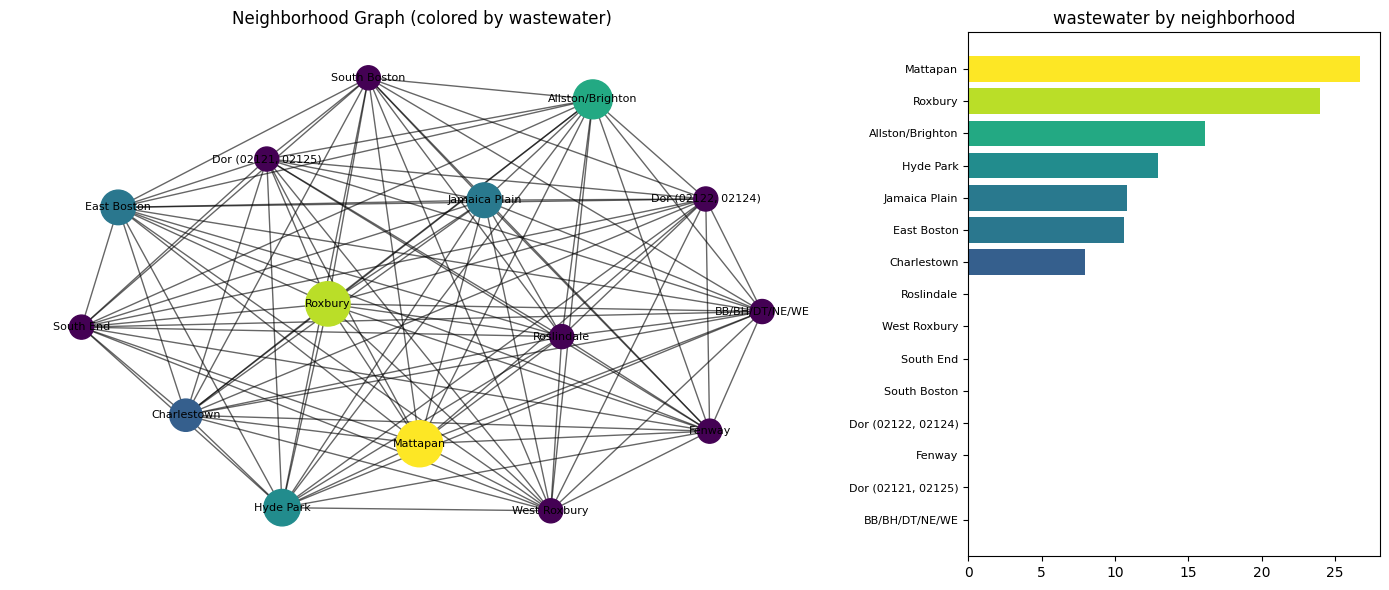

In [3]:
# Visualize neighborhood graph with node features
# Requires: networkx, matplotlib, pandas
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd

# Ensure the dataset and processor objects exist (created earlier in the notebook)
try:
    ds = dataset
    proc = processor
except NameError:
    raise RuntimeError("`dataset` or `processor` not found. Run the dataset creation cell first.")

edge_index = ds.edge_index
# edge_index is (2, E) as a torch tensor - convert to list of edge tuples
if isinstance(edge_index, torch.Tensor):
    edges = edge_index.cpu().numpy().T
else:
    edges = np.array(edge_index).T

G = nx.Graph()
n_nodes = len(proc.neighborhoods)
G.add_nodes_from(range(n_nodes))
# Add edges (ensure ints)
G.add_edges_from([ (int(a), int(b)) for a, b in edges ])

# Attempt to extract a numeric feature per neighborhood (prefer wastewater then flu_rate)
feature_vals = []
feature_label = None
for name in proc.neighborhoods:
    val = np.nan
    if name in ds.neighborhood_features:
        df = ds.neighborhood_features[name]
        if hasattr(df, 'columns'):
            if 'wastewater' in df.columns:
                feature_label = 'wastewater'
                col = 'wastewater'
            elif 'flu_rate' in df.columns:
                feature_label = 'flu_rate'
                col = 'flu_rate'
            else:
                col = None
            if col is not None:
                try:
                    vals = pd.to_numeric(df[col], errors='coerce').values
                    val = np.nanmean(vals)
                except Exception:
                    val = np.nan
    feature_vals.append(val)

feature_vals = np.array(feature_vals, dtype=float)
if np.all(np.isnan(feature_vals)):
    # fallback to node degree
    degs = np.array([G.degree(i) for i in range(n_nodes)], dtype=float)
    feature_vals = degs
    feature_label = 'degree'

# replace NaN with zeros and normalize
feature_vals = np.nan_to_num(feature_vals, nan=0.0)
minv, maxv = feature_vals.min(), feature_vals.max()
if maxv > minv:
    norm = (feature_vals - minv) / (maxv - minv)
else:
    norm = np.zeros_like(feature_vals)

node_colors = plt.cm.viridis(norm)
node_sizes = 300 + norm * 800

fig, axes = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios':[2,1]})
ax = axes[0]
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, ax=ax)
nx.draw_networkx_edges(G, pos, alpha=0.6, ax=ax)
labels = {i: proc.neighborhoods[i] for i in range(n_nodes)}
nx.draw_networkx_labels(G, pos, labels, font_size=8, ax=ax)
ax.set_title(f'Neighborhood Graph (colored by {feature_label})')
ax.axis('off')

ax2 = axes[1]
order = np.argsort(feature_vals)[::-1]
colors_bar = plt.cm.viridis((feature_vals[order]-minv)/(maxv-minv) if maxv>minv else np.zeros(n_nodes))
ax2.barh(range(n_nodes), feature_vals[order], color=colors_bar)
ax2.set_yticks(range(n_nodes))
ax2.set_yticklabels([proc.neighborhoods[i] for i in order], fontsize=8)
ax2.invert_yaxis()
ax2.set_title(f'{feature_label} by neighborhood')
plt.tight_layout()
plt.show()

In [ ]:
prediction = predict_for_week(model, processor, data_dict,
                               target_year=2025, target_week=5)
print(f"\nPredicted ED visits for week 5 of 2025: {prediction:.2f}")

   Base DataFrame shape: (1447, 65)
   Base DataFrame columns: ['year', 'week_of_year', 'ed_count', 'ed_percentage', 'temp_date', 'year_month', 'month', 'Age Group_18-44', 'Age Group_45-64', 'Age Group_5-17', 'Age Group_65+', 'Age Group_<5', 'Gender_Female', 'Gender_Male', 'Neighborhood_Allston/Brighton', 'Neighborhood_BB/BH/DT/NE/WE', 'Neighborhood_Charlestown', 'Neighborhood_Dor (02121, 02125)', 'Neighborhood_Dor (02122, 02124)', 'Neighborhood_East Boston', 'Neighborhood_Fenway', 'Neighborhood_Hyde Park', 'Neighborhood_Jamaica Plain', 'Neighborhood_Mattapan', 'Neighborhood_Roslindale', 'Neighborhood_Roxbury', 'Neighborhood_South Boston', 'Neighborhood_South End', 'Neighborhood_West Roxbury', 'Race/Ethnicity_Asian', 'Race/Ethnicity_Black', 'Race/Ethnicity_Latinx', 'Race/Ethnicity_Multirace', 'Race/Ethnicity_Other', 'Race/Ethnicity_Unknown', 'Race/Ethnicity_White', 'Zip_02108', 'Zip_02109', 'Zip_02110', 'Zip_02111', 'Zip_02113', 'Zip_02114', 'Zip_02115', 'Zip_02116', 'Zip_02118', 'Zip_

AttributeError: 'NoneType' object has no attribute 'max'